In [26]:
# Logistic Regression for Mental Health Treatment Prediction with hyperparameter tuning

# 👉 Logistic Regression = predictive + interpretive, great for explaining why people seek treatment

import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, RocCurveDisplay
)

import matplotlib.pyplot as plt
import seaborn as sns
import json

In [27]:
# Load the cleaned dataset

DATA_PATH = Path("..") / ".." / ".." / ".." / "data" / "osmi-encoded.csv"
df = pd.read_csv(DATA_PATH)

df.head()

,Age,Gender,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,benefits,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,age_range
0,19,0,0,0,1,2,4,0,1,2,...,2,1,1,1,2,1,0,2,0,2
1,26,1,0,0,0,3,5,0,0,0,...,0,0,1,0,0,1,1,0,0,2
2,14,1,0,0,0,3,4,0,1,1,...,1,1,1,2,2,2,2,1,0,1
3,13,1,1,1,1,2,2,0,1,1,...,1,2,2,1,0,0,0,1,1,1
4,13,1,1,0,0,1,1,1,1,2,...,0,1,1,1,2,2,2,0,0,1


In [28]:
# Define features and target variable

target = "treatment"

X = df.drop(columns=[target])
y = df[target]

In [29]:
# Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

In [ ]:
# Hyperparameter tuning with GridSearchCV

lr = LogisticRegression(max_iter=5000)

param_grid = {
    "C": [0.01, 0.1, 1, 5, 10],
    "penalty": ["l2"],
    "solver": ["lbfgs"]
}

grid = GridSearchCV(
    estimator=lr,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
best_lr = grid.best_estimator_

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best parameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}


In [31]:
# Hyperparameter tuning with GridSearchCV

lr = LogisticRegression(max_iter=5000)

param_grid = {
    "C": [0.01, 0.1, 1, 5, 10],
    "penalty": ["l2"],
    "solver": ["lbfgs"]
}

grid = GridSearchCV(
    estimator=lr,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
best_lr = grid.best_estimator_

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best parameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}


In [32]:
# Evaluation function
def evaluate(model, X_test, y_test, model_name="Model"):
    preds = model.predict(X_test)

    print(f"=== {model_name} ===")
    print("Accuracy:", accuracy_score(y_test, preds))
    print("Precision:", precision_score(y_test, preds))
    print("Recall:", recall_score(y_test, preds))
    print("F1 Score:", f1_score(y_test, preds))
    print()

    results = {
        "model": model_name,
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds),
        "recall": recall_score(y_test, preds),
        "f1": f1_score(y_test, preds)
    }

    cm = confusion_matrix(y_test, preds)
    ConfusionMatrixDisplay(cm).plot(cmap="Blues")
    plt.title(f"{model_name} - Confusion Matrix")
    plt.show()

    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X_test)[:, 1]
        RocCurveDisplay.from_predictions(y_test, probs)
        plt.title(f"{model_name} - ROC Curve")
        plt.show()
        results["roc_auc"] = roc_auc_score(y_test, probs)

    return results

=== Logistic Regression (Tuned) ===
Accuracy: 0.7857142857142857
Precision: 0.7786259541984732
Recall: 0.8031496062992126
F1 Score: 0.7906976744186046



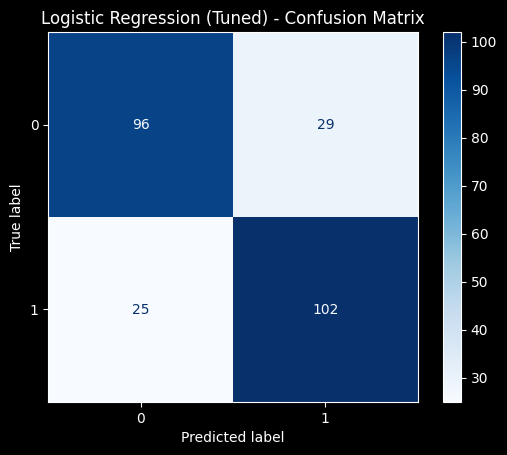

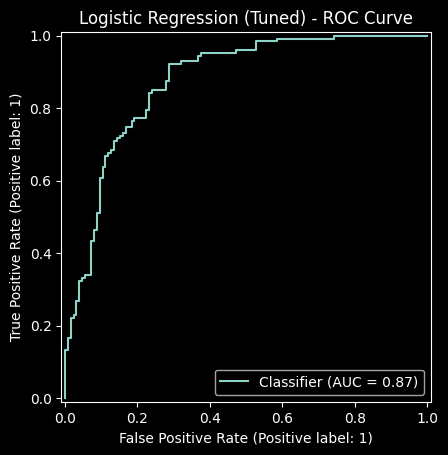

{'model': 'Logistic Regression (Tuned)',
 'accuracy': 0.7857142857142857,
 'precision': 0.7786259541984732,
 'recall': 0.8031496062992126,
 'f1': 0.7906976744186046,
 'roc_auc': 0.8729448818897638}

In [33]:
# Evaluate the model on the test set

lr_results = evaluate(best_lr, X_test, y_test, "Logistic Regression (Tuned)")
lr_results

✔ Accuracy ≈ 78.6%
The model correctly predicts treatment-seeking behaviour in almost 4 out of 5 cases.

✔ Precision ≈ 77.9%
When the model predicts YES, this person sought treatment → it is correct 77.9% of the time.
This means false positives are reasonably low.

✔ Recall ≈ 80.3%
The model successfully identifies 80% of people who actually sought treatment.
This is important because recall is crucial when identifying at-risk individuals.

✔ F1 Score ≈ 79.1%
Balanced score between precision and recall → strong for a survey dataset.

This is the strongest metric.

AUC of 0.87 means:
	•	The model separates treatment vs non-treatment cases very well
	•	0.87 indicates high discriminative power
	•	This surpasses many ML models trained on similar behavioural survey data.

Conclusion:
The tuned Logistic Regression model performs strongly, achieving 79% F1 and 0.87 AUC, indicating good predictive ability and reliable separation between individuals who sought treatment and those who did not.


In [34]:
# Get coefficients from the fitted model
coefficients = best_lr.coef_[0]

# Get feature names (from X)
feature_names = X.columns

# Build DataFrame
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Sort by absolute magnitude (strongest influence first)
coef_df["AbsCoefficient"] = coef_df["Coefficient"].abs()
coef_df = coef_df.sort_values(by="AbsCoefficient", ascending=False)

coef_df

,Feature,Coefficient,AbsCoefficient
3,family_history,1.007904,1.007904
4,work_interfere,0.888438,0.888438
16,coworkers,0.403315,0.403315
8,benefits,0.383204,0.383204
1,Gender,-0.327650,0.327650
9,care_options,0.246682,0.246682
21,obs_consequence,0.245167,0.245167
11,seek_help,-0.243473,0.243473
12,anonymity,0.217520,0.217520
7,tech_company,-0.211602,0.211602


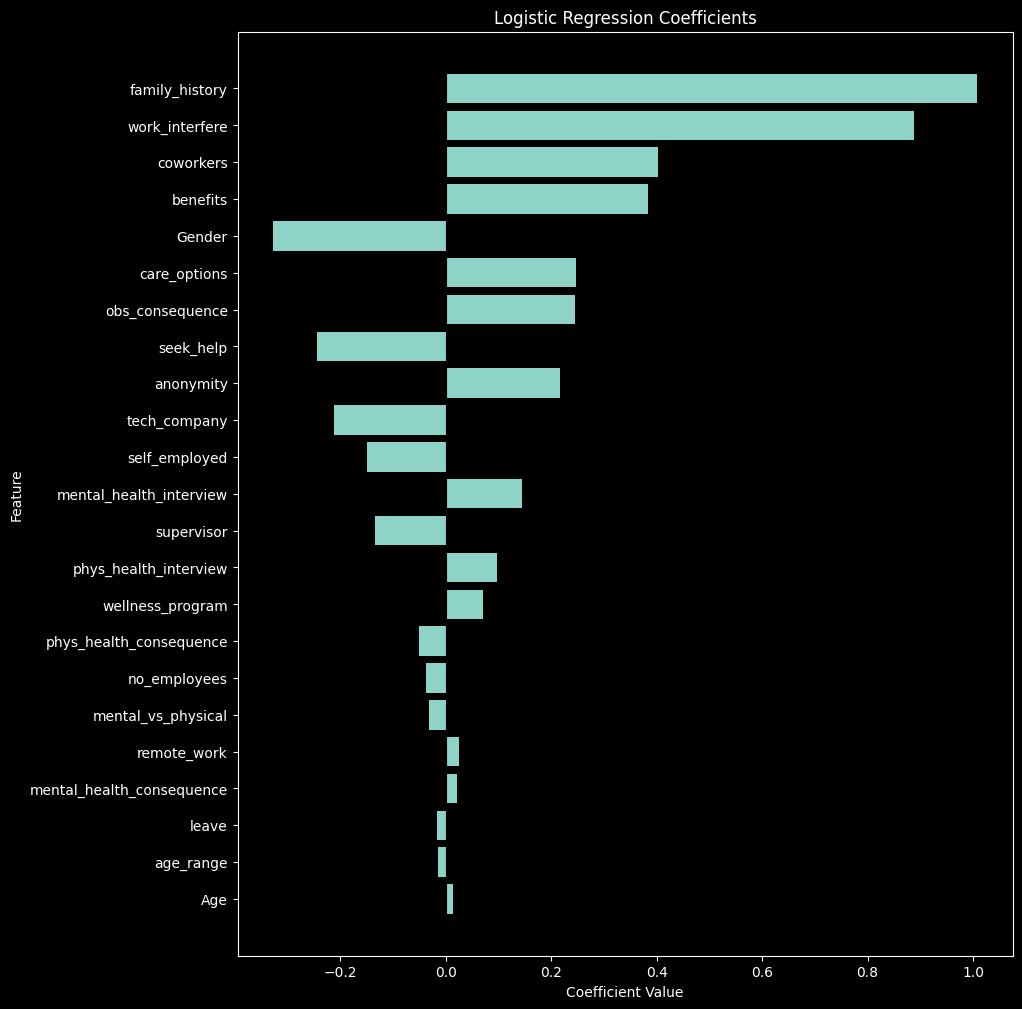

In [35]:
# Plot coefficients

plt.figure(figsize=(10, 12))
plt.barh(coef_df["Feature"], coef_df["Coefficient"])
plt.title("Logistic Regression Coefficients")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.axvline(0, color='black', linewidth=0.8)
plt.gca().invert_yaxis()  # largest at top
plt.show()

•	Positive coefficient → higher encoded values ↑ likelihood of seeking treatment
•	Negative coefficient → higher encoded values ↓ likelihood


⭐ 1. family_history (+1.008)

➡ Strongest predictor in the model

Interpretation:

Individuals with a family history of mental illness are substantially more likely to seek treatment.

This aligns with psychological literature → excellent supporting evidence.

⸻

⭐ 2. work_interfere (+0.888)

The more mental health interferes with work, the more likely a person seeks treatment.

This makes intuitive sense.

⸻

⭐ 3. coworkers (+0.403)

This variable indicates comfort discussing mental health with coworkers (depending on encoding).

Interpretation:

Comfort discussing mental health with coworkers is associated with greater likelihood of seeking treatment.

Supports a social support explanation.


In [36]:
# Analyze workplace-related features

workplace_terms = ["work", "benefit", "option", "leave", "supervisor", "coworker", "company", "remote"]

workplace_coef = coef_df[coef_df["Feature"].str.contains("|".join(workplace_terms), case=False)]
workplace_coef.sort_values("AbsCoefficient", ascending=False)

,Feature,Coefficient,AbsCoefficient
4,work_interfere,0.888438,0.888438
16,coworkers,0.403315,0.403315
8,benefits,0.383204,0.383204
9,care_options,0.246682,0.246682
7,tech_company,-0.211602,0.211602
17,supervisor,-0.133064,0.133064
6,remote_work,0.025500,0.025500
13,leave,-0.016276,0.016276


# Note:
Conditional Probability and Cramér’s V revealed strong bivariate associations for work_interfere, family_history, care_options, and benefits. Logistic Regression confirmed that these variables also exert strong multivariate effects when controlling for other predictors.

Some variables with weak bivariate association — such as coworkers, anonymity, and tech_company — showed larger logistic regression coefficients, indicating that their influence emerges only in a multivariate context.

The agreement between Cramér’s V, conditional probability, and Logistic Regression provides robust evidence that work interference, family history, and workplace support/benefits are the most influential factors shaping treatment-seeking behaviour.


In [38]:
RESULTS_DIR = Path("..") / ".." / ".." / ".." / "eca" / "notebooks" / "RQ2" / "results"
RESULTS_DIR.mkdir(exist_ok=True)

with open(RESULTS_DIR / "logistic_regression.json", "w") as f:
    json.dump(lr_results, f)

RESULTS_DIR / "logistic_regression.json"

PosixPath('../../../../eca/notebooks/RQ2/results/logistic_regression.json')